# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.optimize import minimize
import statsmodels.api as sm

# Data Import

In [2]:
stat_xl = pd.read_excel('stationnary_data.xlsx', index_col=0, parse_dates=True)
y_parse = pd.read_excel('y_sparse.xlsx', index_col=0, parse_dates=True)

In [3]:
series_names = stat_xl.columns.tolist()
gdp_name = y_parse.columns[0]

In [4]:
gdp_diff_df = y_parse.dropna().diff()
gdp_diff_df.columns = [gdp_name]
gdp_diff_df

,GDP
Date,
1959-03-31,NaN
1959-06-30,1.4
1959-09-30,-9.0
1959-12-31,0.8
1960-03-31,8.2
...,...
2024-09-30,-0.3
2024-12-31,-1.4
2025-03-31,-2.5


In [5]:
stat_xl

,SP,IP,Emply,Exptn,PI,LEI,Manu,Oil,TERM
Date,,,,,,,,,
1958-12-31,NaN,NaN,NaN,NaN,NaN,99.6114,NaN,NaN,NaN
1959-01-31,NaN,0.014795,0.007517,NaN,NaN,100.0065,NaN,NaN,NaN
1959-02-28,-0.000180,0.019393,0.003994,NaN,0.003621,100.3623,NaN,NaN,NaN
1959-03-31,0.000541,0.014306,0.006168,NaN,0.007325,100.6661,NaN,NaN,NaN
1959-04-30,0.038048,0.021074,0.005774,NaN,0.007029,100.8976,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-09-30,0.034714,0.000699,0.000677,4.009150,0.000769,NaN,-0.001373,-0.013973,0.460000
2025-10-31,0.022433,-0.000560,-0.000658,3.981549,NaN,NaN,NaN,-0.049189,0.447727
2025-11-30,0.001299,0.001745,0.000401,3.931826,NaN,NaN,NaN,-0.013725,0.438889


In [6]:
final_data = (
    stat_xl
    .merge(gdp_diff_df, left_index=True, right_index=True, how="left")
)


In [7]:
final_data

,SP,IP,Emply,Exptn,PI,LEI,Manu,Oil,TERM,GDP
Date,,,,,,,,,,
1958-12-31,NaN,NaN,NaN,NaN,NaN,99.6114,NaN,NaN,NaN,NaN
1959-01-31,NaN,0.014795,0.007517,NaN,NaN,100.0065,NaN,NaN,NaN,NaN
1959-02-28,-0.000180,0.019393,0.003994,NaN,0.003621,100.3623,NaN,NaN,NaN,NaN
1959-03-31,0.000541,0.014306,0.006168,NaN,0.007325,100.6661,NaN,NaN,NaN,NaN
1959-04-30,0.038048,0.021074,0.005774,NaN,0.007029,100.8976,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-09-30,0.034714,0.000699,0.000677,4.009150,0.000769,NaN,-0.001373,-0.013973,0.460000,0.5
2025-10-31,0.022433,-0.000560,-0.000658,3.981549,NaN,NaN,NaN,-0.049189,0.447727,NaN
2025-11-30,0.001299,0.001745,0.000401,3.931826,NaN,NaN,NaN,-0.013725,0.438889,NaN


# Kalman Filter

In [8]:
def kalman_loglik_two_series(df, rho, d1, d2, gamma1, gamma2, sig2_u1, sig2_u2,
                             names, x0=None, P0=None, jitter_R=1e-8):
    """
    Log-vraisemblance (Kalman) du modèle:
      f_t = rho f_{t-1} + eta_t,      Var(eta)=1  (normalisation)
      u1_t= d1 u1_{t-1} + eps1_t,     Var(eps1)=sig2_u1
      u2_t= d2 u2_{t-1} + eps2_t,     Var(eps2)=sig2_u2
      gdp_t = gamma1 f_t + u1_t       (souvent manquant)
      x_t   = gamma2 f_t + u2_t       (souvent observé)

    df: index HF, colonnes gdp et x, gdp = NaN hors dates LF.
    """
    y = df.loc[:, list(names)].values.astype(float)
    T, k = y.shape
    assert k == 2

    # Matrices
    G = np.array([[rho, 0.0, 0.0],
                  [0.0, d1, 0.0],
                  [0.0, 0.0, d2]], dtype=float)

    # sigma_f^2 = 1 (normalisation)
    Q = np.diag([1.0, sig2_u1, sig2_u2]).astype(float)

    Z = np.array([[gamma1, 1.0, 0.0],
                  [gamma2, 0.0, 1.0]], dtype=float)

    R = jitter_R * np.eye(2)

    p = 3
    I = np.eye(p)

    if x0 is None:
        a_t = np.zeros(p)
    else:
        a_t = np.asarray(x0, float).reshape(p)

    if P0 is None:
        P_t = np.eye(p) * 1e2
    else:
        P_t = np.asarray(P0, float).reshape(p, p)

    ll = 0.0

    for t in range(T):
        # predict
        a_pred = G @ a_t
        P_pred = G @ P_t @ G.T + Q

        yt = y[t, :]
        mask = ~np.isnan(yt)
        m = int(mask.sum())

        if m == 0:
            a_t, P_t = a_pred, P_pred
            continue

        y_obs = yt[mask]
        Z_obs = Z[mask, :]
        R_obs = R[np.ix_(mask, mask)]

        v = y_obs - (Z_obs @ a_pred)
        S = Z_obs @ P_pred @ Z_obs.T + R_obs

        # loglik contribution
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            return -np.inf  # S doit être SPD

        # quad form v' S^{-1} v
        try:
            Sinv_v = np.linalg.solve(S, v)
        except np.linalg.LinAlgError:
            S = S + 1e-8 * np.eye(m)
            Sinv_v = np.linalg.solve(S, v)

        ll += -0.5 * (logdet + v @ Sinv_v + m * np.log(2*np.pi))

        # update
        PZt = P_pred @ Z_obs.T
        try:
            K = np.linalg.solve(S, PZt.T).T
        except np.linalg.LinAlgError:
            S = S + 1e-8 * np.eye(m)
            K = np.linalg.solve(S, PZt.T).T

        a_t = a_pred + K @ v
        KH = K @ Z_obs
        P_t = (I - KH) @ P_pred @ (I - KH).T + K @ R_obs @ K.T

    return ll

In [9]:
def fit_ssm_ml(df_hf, names):
    """
    Estime (rho,d1,d2,gamma1,gamma2,sig2_u1,sig2_u2) par ML (Kalman innovations).
    Contraintes stationnaires via tanh, variances via exp.
    """
    def unpack(theta):
        trho, td1, td2, g1, g2, lsu1, lsu2 = theta
        rho = np.tanh(trho)
        d1  = np.tanh(td1)
        d2  = np.tanh(td2)
        sig2_u1 = np.exp(lsu1)
        sig2_u2 = np.exp(lsu2)
        return rho, d1, d2, g1, g2, sig2_u1, sig2_u2

    def neg_ll(theta):
        rho, d1, d2, g1, g2, s1, s2 = unpack(theta)
        ll = kalman_loglik_two_series(df_hf, rho, d1, d2, g1, g2, s1, s2, names=(names[0], names[1]))
        if not np.isfinite(ll):
            return 1e12
        return -ll

    theta0 = np.array([
        np.arctanh(0.8),
        np.arctanh(0.5),
        np.arctanh(0.5),
        1.0,
        1.0,
        np.log(0.5),
        np.log(0.5),
    ], float)

    res = minimize(neg_ll, theta0, method="L-BFGS-B", options={"maxiter": 2000})
    if not res.success:
        raise RuntimeError(res.message)

    rho, d1, d2, g1, g2, s1, s2 = unpack(res.x)
    return {"rho": rho, "d1": d1, "d2": d2, "gamma1": g1, "gamma2": g2, "sig2_u1": s1, "sig2_u2": s2}

In [ ]:
names = [gdp_name, series_names[0]]
params = fit_ssm_ml(final_data, names)


In [ ]:
names

['GDP', 'SP']

In [10]:
def kalman_filter_minimal(df_x, G, Q, a, Z, R, names, x0=None, P0=None, scaler=None):
    """
    Filtre de Kalman:
      alpha_t = a + G alpha_{t-1} + w_t,   w_t ~ N(0,Q)
      y_t     = Z alpha_t + v_t,          v_t ~ N(0,R)

    NaN autorisés dans y_t.

    Si scaler fourni (StandardScaler), on standardise y:
      y_std = (y - mean_) / scale_
    en respectant les NaN.

    Returns dict: a_pred, P_pred, a_filt, P_filt, index
    """
    y = df_x.reindex(columns=names).values.astype(float)
    idx = df_x.index
    T, k = y.shape
    p = G.shape[0]
    I = np.eye(p)

    if x0 is None:
        x0 = np.zeros(p, dtype=float)
    else:
        x0 = np.asarray(x0, dtype=float).reshape(p)

    if P0 is None:
        P0 = np.eye(p, dtype=float) * 1e2
    else:
        P0 = np.asarray(P0, dtype=float).reshape(p, p)

    a = np.asarray(a, dtype=float).reshape(p)

    a_pred = np.zeros((T, p))
    P_pred = np.zeros((T, p, p))
    a_filt = np.zeros((T, p))
    P_filt = np.zeros((T, p, p))

    a_t = x0.copy()
    P_t = P0.copy()

    if scaler is not None:
        mu = np.asarray(scaler.mean_, dtype=float)
        sd = np.asarray(scaler.scale_, dtype=float)
        if mu.shape[0] != k or sd.shape[0] != k:
            raise ValueError("Scaler incompatible: il doit être fit sur df[names] dans le même ordre.")
        sd = np.where(sd == 0.0, 1.0, sd)

    for t in range(T):
        # predict
        a_t_pred = G @ a_t + a
        P_t_pred = G @ P_t @ G.T + Q

        yt = y[t, :]
        mask = ~np.isnan(yt)

        if mask.sum() == 0:
            a_t, P_t = a_t_pred, P_t_pred
        else:
            y_obs = yt[mask]
            if scaler is not None:
                y_obs = (y_obs - mu[mask]) / sd[mask]

            Z_obs = Z[mask, :]
            R_obs = R[np.ix_(mask, mask)]

            v = y_obs - (Z_obs @ a_t_pred)              # innovation
            S = Z_obs @ P_t_pred @ Z_obs.T + R_obs      # cov innovation

            # gain K = P Z' S^{-1} via solve (stable)
            PZt = P_t_pred @ Z_obs.T                    # (p, m)
            try:
                K = np.linalg.solve(S, PZt.T).T         # (p, m)
            except np.linalg.LinAlgError:
                S = S + 1e-8 * np.eye(S.shape[0])
                K = np.linalg.solve(S, PZt.T).T

            a_t = a_t_pred + K @ v

            # Joseph form
            KH = K @ Z_obs
            P_t = (I - KH) @ P_t_pred @ (I - KH).T + K @ R_obs @ K.T

        a_pred[t], P_pred[t] = a_t_pred, P_t_pred
        a_filt[t], P_filt[t] = a_t, P_t

    return {"a_pred": a_pred, "P_pred": P_pred,
            "a_filt": a_filt, "P_filt": P_filt,
            "index": idx}


def build_ssm_two_series_ar1_ml(params, jitter_R=1e-8):

    rho = params['rho']
    d1 = params['d1']
    d2 = params['d2']
    gamma1 = params['gamma1']
    gamma2 = params['gamma2']
    sig2_u1 = params['sig2_u1']
    sig2_u2 = params['sig2_u2']


    G = np.array([[rho, 0.0, 0.0],
                  [0.0, d1, 0.0],
                  [0.0, 0.0, d2]], dtype=float)
    Q = np.diag([1.0, sig2_u1, sig2_u2]).astype(float)  # sigma_f^2 fixé à 1
    a = np.zeros(3)
    Z = np.array([[gamma1, 1.0, 0.0],
                  [gamma2, 0.0, 1.0]], dtype=float)
    R = jitter_R * np.eye(2)
    return G, Q, a, Z, R



In [ ]:
G, Q, a, Z, R = build_ssm_two_series_ar1_ml(params)

x = series_names[0]

kf = kalman_filter_minimal(
    df_x=final_data,
    G=G, Q=Q, a=a, Z=Z, R=R,
    names=[gdp_name,x],
    scaler=None  # idéalement df_hf déjà standardisé colonne par colonne
)

f_filt = kf["a_filt"][:, 0]
f_pred = kf["a_pred"][:, 0]


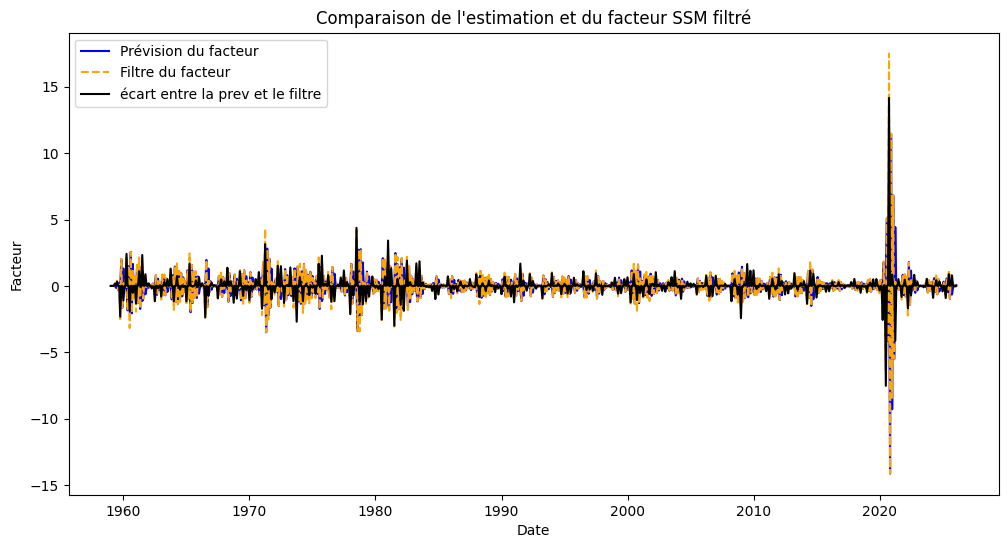

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(kf["index"], f_pred, label='Prévision du facteur', color ='blue')
plt.plot(kf["index"], f_filt, label='Filtre du facteur', color='orange', linestyle='--')
plt.plot(kf["index"], f_filt - f_pred, label='écart entre la prev et le filtre', color='black')

plt.legend()
plt.title('Comparaison de l\'estimation et du facteur SSM filtré')
plt.xlabel('Date')
plt.ylabel('Facteur')
plt.show()

# Helpers

In [11]:
# -----------------------------
# 0) Helpers
# -----------------------------
def quarter_end_months(q_period: pd.Period) -> pd.Timestamp:
    """Dernier mois (fin de trimestre) en fin de mois."""
    return q_period.asfreq("Q").end_time.to_period("M").to_timestamp("M")

def quarter_second_month(q_period: pd.Period) -> pd.Timestamp:
    """2e mois du trimestre en fin de mois: Q1->Feb, Q2->May, Q3->Aug, Q4->Nov."""
    start = q_period.start_time.to_period("M").to_timestamp("M")
    return (start.to_period("M") + 1).to_timestamp("M")  # +1 mois

def to_quarter_period_index(idx):
    """Index -> PeriodIndex trimestriel."""
    return pd.PeriodIndex(idx, freq="Q")

def normalize_full_sample(df: pd.DataFrame):
    mu = df[df.columns[0]].mean()
    sd = df[df.columns[0]].std(ddof=0)
    sd = 1.0 if sd == 0 else sd
    return (df[df.columns[0]] - mu) / sd, mu, sd

# MIDAS

In [52]:
# -----------------------------
# 2) Construire régressseurs MIDAS/ADL-MIDAS
#    (ici: on prend les K derniers mois jusqu'au 2e mois du trimestre)
# -----------------------------
def build_midas_design(gdp_q: pd.Series,
                       x_m: pd.Series,
                       gdp_lags=1,
                       x_month_lags=6,
                       use_second_month=True):
    """
    Construit (Y, X) pour régression type ADL-MIDAS:
      GDP_q = a + sum_{i=1..gdp_lags} b_i GDP_{q-i} + sum_{j=0..x_month_lags-1} c_j x_{m2-j} + e_q
    où x_{m2} = valeur mensuelle au 2e mois du trimestre.

    Retourne DataFrame X (avec constante) et Series Y alignés trimestriellement.
    """
    gdp_q = gdp_q.dropna().copy()
    # s'assurer que x_m est mensuel fin de mois
    x_m = x_m.dropna().copy()

    qs = pd.PeriodIndex(gdp_q.index, freq="Q")
    rows = []
    y = []

    for q in qs:
        # date mensuelle de référence dans le trimestre: 2e mois ou fin de trimestre
        ref_m = quarter_second_month(q) if use_second_month else quarter_end_months(q)
        if ref_m not in x_m.index:
            continue

        # Y: GDP du trimestre q
        y.append(gdp_q.loc[q])

        feat = {}
        # lags GDP
        for L in range(1, gdp_lags + 1):
            qlag = q - L
            if qlag not in gdp_q.index:
                feat = None
                break
            feat[f"gdp_lag{L}"] = gdp_q.loc[qlag]

        if feat is None:
            y.pop()
            continue

        # lags mensuels de x: ref_m, ref_m-1, ..., ref_m-(x_month_lags-1)
        mper = ref_m.to_period("M")
        ok = True
        for j in range(x_month_lags):
            mj = (mper - j).to_timestamp("M")
            if mj not in x_m.index:
                ok = False
                break
            feat[f"x_mlag{j}"] = x_m.loc[mj]
        if not ok:
            y.pop()
            continue

        feat["quarter"] = q
        rows.append(feat)

    X = pd.DataFrame(rows).set_index("quarter")
    Y = pd.Series(y, index=X.index, name="gdp")
    X = sm.add_constant(X, has_constant="add")
    return Y, X

# -----------------------------
# 3) Estimation MIDAS et forecast (h-quarters ahead)
# -----------------------------
def fit_adl_midas(Y, X):
    """OLS ADL-MIDAS."""
    model = sm.OLS(Y.values, X.values).fit()
    return model

def forecast_adl_midas(model, gdp_q_hist, x_m_hist, origin_q, h,
                       gdp_lags=1, x_month_lags=6, use_second_month=True):
    """
    Prévision GDP_{origin_q + h} au temps origin_q, avec info mensuelle jusqu'au 2e mois du trimestre origin_q+h.
    Conformément au papier: on utilise x jusqu'au 2e mois du trimestre à prévoir.
    """
    target_q = origin_q + h
    ref_m = quarter_second_month(target_q) if use_second_month else quarter_end_months(target_q)

    feat = {}
    for L in range(1, gdp_lags + 1):
        qlag = target_q - L
        if qlag not in gdp_q_hist.index:
            return np.nan
        feat[f"gdp_lag{L}"] = gdp_q_hist.loc[qlag]

    mper = ref_m.to_period("M")
    for j in range(x_month_lags):
        mj = (mper - j).to_timestamp("M")
        if mj not in x_m_hist.index:
            return np.nan
        feat[f"x_mlag{j}"] = x_m_hist.loc[mj]

    Xrow = pd.DataFrame([feat])
    Xrow = sm.add_constant(Xrow, has_constant="add")
    yhat = float(model.predict(Xrow.values)[0])
    return yhat

# Forecast Kalman

In [12]:
# ============================================================
# Forecasts "comme le papier" (exercice récursif expanding window)
# - Chaque modèle utilise UNE seule variable mensuelle x_t
# - Prévisions faites avec données mensuelles jusqu'au 2e mois du trimestre
# - Fenêtre d'estimation initiale (ex: 1959Q1–1978Q4), puis expanding
# - Normalisation par la moyenne/variance de l'échantillon COMPLET (full sample)
# - Produit des prévisions 1 à 8 trimestres ahead (h = 1..8)
# ============================================================


# -----------------------------
# 4) SSM (Kalman) : modèle simple type capture (f AR(1), u1 AR(1), u2 AR(1))
#     + estimation ML via innovations (niveau 2)
# -----------------------------
def kalman_filter_states(df_hf, params, names, jitter_R=1e-8):
    """Filtre (renvoie a_pred / a_filt) pour utilisation en forecast."""
    y = df_hf[names].values.astype(float)
    idx = df_hf.index
    T = len(idx)

    rho = params["rho"]; d1=params["d1"]; d2=params["d2"]
    g1 = params["gamma1"]; g2=params["gamma2"]
    s1 = params["sig2_u1"]; s2=params["sig2_u2"]

    G = np.array([[rho, 0.0, 0.0],
                  [0.0, d1, 0.0],
                  [0.0, 0.0, d2]], float)
    Q = np.diag([1.0, s1, s2]).astype(float)
    Z = np.array([[g1, 1.0, 0.0],
                  [g2, 0.0, 1.0]], float)
    R = jitter_R*np.eye(2)

    a = np.zeros(3)
    P = np.eye(3)*1e2
    I = np.eye(3)

    a_pred = np.zeros((T,3))
    a_filt = np.zeros((T,3))

    for t in range(T):
        ap = G @ a
        Pp = G @ P @ G.T + Q

        a_pred[t] = ap

        yt = y[t]
        mask = ~np.isnan(yt)
        if mask.sum() == 0:
            a, P = ap, Pp
        else:
            y_obs = yt[mask]
            Z_obs = Z[mask,:]
            R_obs = R[np.ix_(mask,mask)]
            v = y_obs - Z_obs @ ap
            S = Z_obs @ Pp @ Z_obs.T + R_obs
            PZt = Pp @ Z_obs.T
            try:
                K = np.linalg.solve(S, PZt.T).T
            except np.linalg.LinAlgError:
                S = S + 1e-8*np.eye(S.shape[0])
                K = np.linalg.solve(S, PZt.T).T
            a = ap + K @ v
            KH = K @ Z_obs
            P = (I - KH) @ Pp @ (I - KH).T + K @ R_obs @ K.T

        a_filt[t] = a

    return {"index": idx, "a_pred": a_pred, "a_filt": a_filt, "G": G, "Z": Z}

def forecast_gdp_quarter_ssm(kf_out, params, origin_month, target_q):
    """
    Forecast/nowcast du GDP trimestriel target_q à l'information jusqu'à origin_month (fin de mois).
    On suit l'esprit du papier: origin_month = 2e mois du trimestre target_q.
    Ici, on approxime GDP_q comme la valeur de 'gdp_t' au dernier mois du trimestre
    (car dans le modèle (3.1) le low-freq est traité périodiquement via Z_j).
    Donc:
      GDP_q_hat = E[gdp_{m3} | info jusqu'à m2] = [gamma1,1,0] * E[alpha_{m3} | info jusqu'à m2]
    """
    idx = pd.DatetimeIndex(kf_out["index"])
    if origin_month not in idx:
        return np.nan

    t0 = int(np.where(idx == origin_month)[0][0])
    a0 = kf_out["a_filt"][t0].copy()
    G = kf_out["G"]
    g1 = params["gamma1"]

    # dernier mois du trimestre target_q
    m3 = quarter_end_months(target_q)
    if m3 not in idx:
        # si idx s'arrête avant, on peut projeter en nombre de mois
        step = (m3.to_period("M") - origin_month.to_period("M")).n
    else:
        step = int(np.where(idx == m3)[0][0]) - t0

    if step <= 0:
        return np.nan

    # projection d'état jusqu'à m3
    a = a0
    for _ in range(step):
        a = G @ a

    f_m3, u1_m3 = a[0], a[1]
    gdp_hat = g1 * f_m3 + u1_m3
    return float(gdp_hat)

# -----------------------------
# 5) Exercice récursif expanding window "comme le papier"
# -----------------------------
def recursive_forecast_exercise(gdp_q_col : pd.DataFrame,
                                x_m_col : pd.DataFrame,
                                start_est_q: str,
                                end_est_q: str,
                                names,
                                eval_start_q: str,
                                eval_end_q: str,
                                horizons=range(1,9),
                                gdp_lags=1,
                                x_month_lags=6):
    """
    - Normalise (full sample) GDP et x.
    - Estime récursivement:
       * SSM (ML via Kalman)
    - Prévisions faites avec données mensuelles jusqu'au 2e mois du trimestre à prévoir.
    """

    # --- normalisation full sample (comme le papier) ---
    #gdp_q, gdp_mu, gdp_sd = normalize_full_sample(gdp_q_col.astype(float))
    #x_m, x_mu, x_sd = normalize_full_sample(x_m_col.astype(float))
    gdp_norm, gdp_mu, gdp_sd = normalize_full_sample(gdp_q_col.astype(float))
    x_norm, x_mu, x_sd = normalize_full_sample(x_m_col.astype(float))

    # --- indices trimestriels ---
    gdp_q = gdp_norm.dropna()
    gdp_q.index = pd.PeriodIndex(gdp_q.index, freq="Q")
    gdp_q = gdp_q.groupby(level=0).last().sort_index()


    start_est = pd.Period(start_est_q, freq="Q")
    end_est   = pd.Period(end_est_q,   freq="Q")
    eval_start= pd.Period(eval_start_q,freq="Q")
    eval_end  = pd.Period(eval_end_q,  freq="Q")

    # trimestres évalués
    qs_all = gdp_q.index
    eval_qs = [q for q in qs_all if (q >= eval_start and q <= eval_end)]

    # stockage
    out = []
    # pré-calendrier mensuel (index mensuel fin de mois)
    x_m = x_norm.astype(float).copy()
    x_m.index = pd.DatetimeIndex(x_m.index).to_period("M").to_timestamp("M")
    x_m = x_m.sort_index()

    for origin_q in eval_qs:
        print("ORIGIN:", origin_q)

        # fenêtre d'estimation expanding: de start_est à origin_q-1
        est_end_q = origin_q - 1
        if est_end_q < start_est:
            continue
        gdp_est = gdp_q.loc[start_est:est_end_q].dropna()

        # construire x disponible pour l'estimation:
        # on suppose qu'à chaque trimestre, on n'utilise x que jusqu'au 2e mois
        # => pour l'estimation, il suffit d'avoir x sur tout l'historique mensuel.
        x_est = x_m.copy()


        # --------- (B) SSM estimation (ML) ----------
        # construire df_hf mensuel avec gdp observé aux fins de trimestre de la fenêtre d'estimation
        # et NaN ailleurs. Le GDP du trimestre est placé au dernier mois du trimestre.
        # IMPORTANT: on n'inclut pas d'observation GDP pour le trimestre origin_q (à prévoir).
        start_m = quarter_end_months(start_est).to_period("M").to_timestamp("M") - pd.offsets.MonthEnd(2)  # approx
        end_m   = quarter_second_month(origin_q)  # info set: jusqu'au 2e mois du trimestre origin_q (comme le papier)
        months = pd.date_range(start=start_m, end=end_m, freq="M")

        df_hf = pd.DataFrame(index=months, columns=names, dtype=float)
        df_hf[names[1]] = x_m.reindex(months).values

        # GDP observé seulement pour trimestres <= est_end_q, au dernier mois du trimestre
        for q in gdp_est.index:
            m3 = quarter_end_months(q)
            if m3 in df_hf.index:
                df_hf.loc[m3, names[0]] = gdp_est.loc[q]

        # (il y aura des NaN si x manque : on laisse, le Kalman gère)

        # Estimation ML
        params = fit_ssm_ml(df_hf, names)

        # Filtre jusqu'à end_m (2e mois du trimestre origin_q)
        kf_out = kalman_filter_states(df_hf, params, names)

        # --------- Forecasts h = 1..8 ----------
        for h in horizons:
            #target_q = origin_q + (h - 1)  # h=1 => trimestre origin_q
            target_q = origin_q + h #h=0 => trimestre origin_q

            # SSM: on prédit GDP du trimestre target_q à info jusqu'au 2e mois de origin_q
            # (pour h>1, origin_q est plus tôt, mais dans le papier ils font 2..8 quarters ahead pareil
            #  => tu peux remplacer origin_month par 2e mois de origin_q pour "as-of" constant)
            origin_month = quarter_second_month(origin_q)
            yhat_ssm = forecast_gdp_quarter_ssm(
                kf_out, params, origin_month=origin_month, target_q=target_q
            )

            print(origin_q, target_q)
            
            out.append({
                "origin_q": str(origin_q),
                "target_q": str(target_q),
                "h": h,
                "ssm_hat": yhat_ssm,
                "gdp_real": gdp_q.loc[target_q] if target_q in gdp_q.index else np.nan
            })

    return pd.DataFrame(out)



In [ ]:

# ============================================================
# Appel
# ============================================================

df_forecasts = recursive_forecast_exercise(
    gdp_q_col=final_data[[gdp_name]],
    x_m_col=final_data[[series_names[0]]],
    start_est_q="1958Q1",
    end_est_q="1978Q4",
    names = [gdp_name, series_names[7]],
    eval_start_q="1979Q1",
    eval_end_q="2009Q1",
    horizons=range(1,9),
    gdp_lags=1,
    x_month_lags=6
)
df_forecasts.head()

In [55]:
df = df_forecasts.copy()

In [56]:
# 1) Garder uniquement les observations valides pour le SSM
df_eval = df_forecasts.dropna(subset=["ssm_hat", "gdp_real"]).copy()
df_eval["sq_err"] = (df_eval["ssm_hat"] - df_eval["gdp_real"]) ** 2

# 2) RMSE par horizon selon la formule (1/N_h * somme)
rmse_ssm_by_h = (
    df_eval.groupby("h")
    .agg(
        N_h=("sq_err", "size"),
        RMSE_SSM=("sq_err", lambda s: np.sqrt(s.sum() / len(s)))
    )
    .reset_index()
    .sort_values("h")
)

rmse_ssm_by_h


,h,N_h,RMSE_SSM
0,1,121,0.558491
1,2,121,0.576657
2,3,121,0.562539
3,4,121,0.562120
4,5,121,0.557922
5,6,121,0.559585
6,7,121,0.541224
7,8,121,0.529160


In [59]:
df.to_excel("dataframe_forecast_0.xlsx")
rmse_ssm_by_h.to_excel("rmse_ssm_by_h_0.xlsx")

In [58]:
rmse_ssm_by_h

,h,N_h,RMSE_SSM
0,1,121,0.558491
1,2,121,0.576657
2,3,121,0.562539
3,4,121,0.562120
4,5,121,0.557922
5,6,121,0.559585
6,7,121,0.541224
7,8,121,0.529160


# TEST

In [ ]:
def kalman_filter_states(df_hf, params, names, jitter_R=1e-8):
    """
    Kalman filter pour modèle mixed-frequency
    GDP traité comme FLOW trimestriel
    """
    y = df_hf[names].values.astype(float)
    idx = df_hf.index
    T = len(idx)

    rho = params["rho"]; d1 = params["d1"]; d2 = params["d2"]
    g1  = params["gamma1"]; g2 = params["gamma2"]
    s1  = params["sig2_u1"]; s2 = params["sig2_u2"]

    # --------------------------------------------------
    # Transition des états (INCHANGÉ)
    # --------------------------------------------------
    G = np.array([[rho, 0.0, 0.0],
                  [0.0, d1, 0.0],
                  [0.0, 0.0, d2]], float)

    Q = np.diag([1.0, s1, s2]).astype(float)

    R = jitter_R * np.eye(2)

    a = np.zeros(3)
    P = np.eye(3) * 1e2
    I = np.eye(3)

    a_pred = np.zeros((T, 3))
    a_filt = np.zeros((T, 3))

    # <<< MODIF >>> : mois dans le trimestre (1,2,3)
    months_in_quarter = np.array(
        [(d.month - 1) % 3 + 1 for d in idx]
    )

    for t in range(T):
      if months_in_quarter[t] != 3 and not np.isnan(y[t,0]):
        print("ERREUR: GDP observé hors fin de trimestre", idx[t])


      # ------------------------------
      # Prediction step
      # ------------------------------
      ap = G @ a
      Pp = G @ P @ G.T + Q

      a_pred[t] = ap

      yt = y[t]
      mask = ~np.isnan(yt)

      if mask.sum() == 0:
          a, P = ap, Pp

      else:
          # <<< MODIF >>> : Z_t dépend du mois (FLOW)
          Z_t = np.zeros((2, 3))

          # x mensuel (toujours observé)
          Z_t[1, :] = [g2, 0.0, 1.0]

          # GDP trimestriel observé SEULEMENT au 3e mois
          if months_in_quarter[t] == 3:
              Z_t[0, :] = [g1 / 3.0, 1.0 / 3.0, 0.0]
          else:
              Z_t[0, :] = [0.0, 0.0, 0.0]

          y_obs = yt[mask]
          Z_obs = Z_t[mask, :]
          R_obs = R[np.ix_(mask, mask)]

          v = y_obs - Z_obs @ ap
          S = Z_obs @ Pp @ Z_obs.T + R_obs
          PZt = Pp @ Z_obs.T

          try:
              K = np.linalg.solve(S, PZt.T).T
          except np.linalg.LinAlgError:
              S += 1e-8 * np.eye(S.shape[0])
              K = np.linalg.solve(S, PZt.T).T

          a = ap + K @ v
          KH = K @ Z_obs
          P = (I - KH) @ Pp @ (I - KH).T + K @ R_obs @ K.T

      a_filt[t] = a

    return {
        "index": idx,
        "a_pred": a_pred,
        "a_filt": a_filt,
        "G": G,
    }


In [ ]:
def forecast_gdp_quarter_ssm(kf_out, params, origin_month, target_q):
    """
    Forecast/nowcast du GDP trimestriel (FLOW)
    GDP_q = moyenne des 3 mois du trimestre
    """
    idx = pd.DatetimeIndex(kf_out["index"])
    if origin_month not in idx:
        return np.nan

    # état filtré à l'origine (2e mois)
    t0 = int(np.where(idx == origin_month)[0][0])
    a = kf_out["a_filt"][t0].copy()

    G = kf_out["G"]
    g1 = params["gamma1"]

    # mois fin du trimestre cible
    m3 = quarter_end_months(target_q)

    # nombre de mois à projeter
    if m3 in idx:
        step_total = int(np.where(idx == m3)[0][0]) - t0
    else:
        step_total = (m3.to_period("M") - origin_month.to_period("M")).n

    if step_total <= 0:
        return np.nan

    # --------------------------------------------------
    # Projection mois par mois + agrégation FLOW
    # --------------------------------------------------
    gdp_sum = 0.0
    months_counted = 0

    for i in range(step_total):
        a = G @ a

        current_month = origin_month + pd.offsets.MonthEnd(i + 1)
        month_in_quarter = (current_month.month - 1) % 3 + 1

        if month_in_quarter in (1, 2, 3):
            gdp_sum += g1 * a[0] + a[1]
            months_counted += 1




    # sécurité
    if months_counted != 3:
        return np.nan

    gdp_hat = gdp_sum / 3.0
    return float(gdp_hat)


In [ ]:
def recursive_forecast_exercise(
    gdp_q_col: pd.DataFrame,
    x_m_col: pd.DataFrame,
    start_est_q: str,
    end_est_q: str,
    names,
    eval_start_q: str,
    eval_end_q: str,
    horizons=range(1, 9),
):
    """
    Recursive expanding-window forecast exercise
    Normalisation FULL SAMPLE (comme Bai–Ghysels–Wright)
    """

    # ========================================================
    # 1) NORMALISATION FULL SAMPLE (UNE FOIS)
    # ========================================================
    gdp_norm, gdp_mu, gdp_sd = normalize_full_sample(
        gdp_q_col.astype(float)
    )
    x_norm, x_mu, x_sd = normalize_full_sample(
        x_m_col.astype(float)
    )

    # ========================================================
    # 2) GDP TRIMESTRIEL NORMALISÉ
    # ========================================================
    gdp_q = gdp_norm.dropna()
    gdp_q.index = pd.PeriodIndex(gdp_q.index, freq="Q")
    gdp_q = gdp_q.groupby(level=0).last().sort_index()

    # ========================================================
    # 3) SÉRIE MENSUELLE NORMALISÉE
    # ========================================================
    x_m = x_norm.copy()
    x_m.index = pd.DatetimeIndex(x_m.index).to_period("M").to_timestamp("M")
    x_m = x_m.sort_index()

    # Sanity check
    print("STD GDP (norm):", float(gdp_q.std()))
    print("STD x   (norm):", float(x_m.std()))

    # ========================================================
    # 4) INDEX TEMPORELS
    # ========================================================
    start_est = pd.Period(start_est_q, freq="Q")
    end_est   = pd.Period(end_est_q,   freq="Q")
    eval_start= pd.Period(eval_start_q,freq="Q")
    eval_end  = pd.Period(eval_end_q,  freq="Q")

    qs_all = gdp_q.index
    eval_qs = [q for q in qs_all if eval_start <= q <= eval_end]

    out = []

    # ========================================================
    # 5) BOUCLE RÉCURSIVE
    # ========================================================
    for origin_q in eval_qs:
        #print("ORIGIN:", origin_q)

        est_end_q = origin_q - 1
        if est_end_q < start_est:
            continue

        gdp_est = gdp_q.loc[start_est:est_end_q].dropna()

        # ----------------------------------------------------
        # Construction du calendrier mensuel HF
        # ----------------------------------------------------
        start_m = quarter_end_months(start_est) - pd.offsets.MonthEnd(2)
        end_m   = quarter_second_month(origin_q)

        months = pd.date_range(start=start_m, end=end_m, freq="M")

        df_hf = pd.DataFrame(index=months, columns=names, dtype=float)

        # x mensuel normalisé
        df_hf[names[1]] = x_m.reindex(months)

        # GDP trimestriel normalisé observé seulement
        for q in gdp_est.index:
            m3 = quarter_end_months(q)
            if m3 in df_hf.index:
                df_hf.loc[m3, names[0]] = gdp_est.loc[q]

        # ----------------------------------------------------
        # Estimation SSM (ML)
        # ----------------------------------------------------
        params = fit_ssm_ml(df_hf, names)

        # Filtre Kalman jusqu'au 2e mois du trimestre origin_q
        kf_out = kalman_filter_states(df_hf, params, names)

        origin_month = quarter_second_month(origin_q)

        # ----------------------------------------------------
        # Prévisions h = 1..8
        # ----------------------------------------------------
        for h in horizons:
            target_q = origin_q + (h - 1)


            yhat = forecast_gdp_quarter_ssm(
                kf_out,
                params,
                origin_month=origin_month,
                target_q=target_q,
            )

            out.append({
                "origin_q": str(origin_q),
                "target_q": str(target_q),
                "h": h,
                "ssm_hat": yhat,
                "gdp_real": gdp_q.loc[target_q] if target_q in gdp_q.index else np.nan,
            })

    return pd.DataFrame(out)


In [ ]:
df_forecasts = recursive_forecast_exercise(
    gdp_q_col=final_data[[gdp_name]],
    x_m_col=final_data[[series_names[7]]],
    start_est_q="1982Q1",
    end_est_q="1992Q4",
    names=[gdp_name, series_names[7]],
    eval_start_q="1993Q1",
    eval_end_q="2009Q1",
    horizons=range(1, 9),
)


In [ ]:
df_forecasts

In [ ]:
# 1) Garder uniquement les observations valides pour le SSM
df_eval = df_forecasts.dropna(subset=["ssm_hat", "gdp_real"]).copy()
df_eval["sq_err"] = (df_eval["ssm_hat"] - df_eval["gdp_real"]) ** 2

# 2) RMSE par horizon selon la formule (1/N_h * somme)
rmse_ssm_by_h = (
    df_eval.groupby("h")
    .agg(
        N_h=("sq_err", "size"),
        RMSE_SSM=("sq_err", lambda s: np.sqrt(s.sum() / len(s)))
    )
    .reset_index()
    .sort_values("h")
)

rmse_ssm_by_h


# Boucle à run

In [ ]:
for i in range(len(stat_xl.columns)):
  names = [gdp_name, series_names[i]]
  params = fit_ssm_ml(final_data, names)

  G, Q, a, Z, R = build_ssm_two_series_ar1_ml(params)

  x = series_names[i]

  kf = kalman_filter_minimal(
      df_x=final_data,
      G=G, Q=Q, a=a, Z=Z, R=R,
      names=[gdp_name,x],
      scaler=None  # idéalement df_hf déjà standardisé colonne par colonne
  )

  f_filt = kf["a_filt"][:, 0]
  f_pred = kf["a_pred"][:, 0]

  first_date = [0,1,2,4,5,8]
  second_date = [3] #EXPTN
  third_date = [6]
  fourth_date = [7] #oil

  if not (i in first_date or i in third_date or i in fourth_date):
    continue
  
  elif i in first_date:
    df_forecasts = recursive_forecast_exercise(
      gdp_q_col=final_data[[gdp_name]],
      x_m_col=final_data[[series_names[i]]],
      start_est_q="1958Q1",
      end_est_q="1990Q4",
      names = [gdp_name, series_names[i]],
      eval_start_q="1991Q1",
      eval_end_q="2023Q4",
      horizons=range(1,9),
      gdp_lags=1,
      x_month_lags=6
    )
  elif i in second_date:
    df_forecasts = recursive_forecast_exercise(
      gdp_q_col=final_data[[gdp_name]],
      x_m_col=final_data[[series_names[i]]],
      start_est_q="1978Q1",
      end_est_q="1990Q4",
      names = [gdp_name, series_names[i]],
      eval_start_q="1991Q1",
      eval_end_q="2023Q4",
      horizons=range(1,9),
      gdp_lags=1,
      x_month_lags=6
    )
  elif i in third_date:
    df_forecasts = recursive_forecast_exercise(
      gdp_q_col=final_data[[gdp_name]],
      x_m_col=final_data[[series_names[i]]],
      start_est_q="1967Q1",
      end_est_q="1990Q4",
      names = [gdp_name, series_names[i]],
      eval_start_q="1991Q1",
      eval_end_q="2023Q4",
      horizons=range(1,9),
      gdp_lags=1,
      x_month_lags=6
    )
  elif i in fourth_date:
    df_forecasts = recursive_forecast_exercise(
      gdp_q_col=final_data[[gdp_name]],
      x_m_col=final_data[[series_names[i]]],
      start_est_q="1982Q1",
      end_est_q="1992Q4",
      names = [gdp_name, series_names[i]],
      eval_start_q="1993Q1",
      eval_end_q="2023Q4",
      horizons=range(1,9),
      gdp_lags=1,
      x_month_lags=6
    )

  # 1) Garder uniquement les observations valides pour le SSM
  df_eval = df_forecasts.dropna(subset=["ssm_hat", "gdp_real"]).copy()
  df_eval["sq_err"] = (df_eval["ssm_hat"] - df_eval["gdp_real"]) ** 2

  # 2) RMSE par horizon selon la formule (1/N_h * somme)
  rmse_ssm_by_h = (
      df_eval.groupby("h")
      .agg(
          N_h=("sq_err", "size"),
          RMSE_SSM=("sq_err", lambda s: np.sqrt(s.sum() / len(s)))
      )
      .reset_index()
      .sort_values("h")
  )
  df_forecasts.to_excel(f"forecast_{i}_2023.xlsx")
  rmse_ssm_by_h.to_excel(f"rmse_{i}_2024.xlsx")

ORIGIN: 1991Q1


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_97383/3190850397.py:177: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start=start_m, end=end_m, freq="M")


1991Q1 1991Q2
1991Q1 1991Q3
1991Q1 1991Q4
1991Q1 1992Q1
1991Q1 1992Q2
1991Q1 1992Q3
1991Q1 1992Q4
1991Q1 1993Q1
ORIGIN: 1991Q2


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_97383/3190850397.py:177: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start=start_m, end=end_m, freq="M")


1991Q2 1991Q3
1991Q2 1991Q4
1991Q2 1992Q1
1991Q2 1992Q2
1991Q2 1992Q3
1991Q2 1992Q4
1991Q2 1993Q1
1991Q2 1993Q2
ORIGIN: 1991Q3


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_97383/3190850397.py:177: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start=start_m, end=end_m, freq="M")


1991Q3 1991Q4
1991Q3 1992Q1
1991Q3 1992Q2
1991Q3 1992Q3
1991Q3 1992Q4
1991Q3 1993Q1
1991Q3 1993Q2
1991Q3 1993Q3
ORIGIN: 1991Q4


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_97383/3190850397.py:177: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start=start_m, end=end_m, freq="M")


1991Q4 1992Q1
1991Q4 1992Q2
1991Q4 1992Q3
1991Q4 1992Q4
1991Q4 1993Q1
1991Q4 1993Q2
1991Q4 1993Q3
1991Q4 1993Q4
ORIGIN: 1992Q1


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_97383/3190850397.py:177: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start=start_m, end=end_m, freq="M")


In [63]:
stat_xl

,SP,IP,Emply,Exptn,PI,LEI,Manu,Oil,TERM
Date,,,,,,,,,
1958-12-31,NaN,NaN,NaN,NaN,NaN,99.6114,NaN,NaN,NaN
1959-01-31,NaN,0.014795,0.007517,NaN,NaN,100.0065,NaN,0.000000,NaN
1959-02-28,-0.000180,0.019393,0.003994,NaN,0.003621,100.3623,NaN,0.000000,NaN
1959-03-31,0.000541,0.014306,0.006168,NaN,0.007325,100.6661,NaN,-0.010050,NaN
1959-04-30,0.038048,0.021074,0.005774,NaN,0.007029,100.8976,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
2025-09-30,0.034714,0.000699,0.000677,4.009150,0.000769,NaN,-0.001373,-0.013973,0.460000
2025-10-31,0.022433,-0.000560,-0.000658,3.981549,NaN,NaN,NaN,-0.049189,0.447727
2025-11-30,0.001299,0.001745,0.000401,3.931826,NaN,NaN,NaN,-0.013725,0.438889


# TABLE 1

![TABLE 1 du papier](TABLE1.png)
